# Preliminary data analysis: pilot movie free-viewing

This notebook is a ground-up first pass through the pilot data. The goal is not to do statistics yet. The goal is to learn what files we have, what shapes they have, and how the EyeLink stream turns into analysis tables.

The important files are:

- `demo_2026-03-05_1439.mat`: MATLAB output. Python can read the `cclab` config, but the MATLAB `Results` table is stored as an opaque MATLAB object.
- `demo.edf`: raw proprietary EyeLink recording.
- `demo.asc`: text export from `demo.edf`, made with `edf2asc`. This notebook can create it if it is missing and `edf2asc` is installed.

## 1. Imports and paths

Run this notebook from the project root or from `Code/`; the path setup below handles both.

In [19]:
from pathlib import Path
import math
import re
import shutil
import subprocess

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

plt.style.use("default")

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "Data").exists() else cwd.parent
PILOT_DIR = PROJECT_ROOT / "Data" / "Pilot data" / "demo_2026-03-05_1439"
MAT_PATH = PILOT_DIR / "demo_2026-03-05_1439.mat"
EDF_PATH = PILOT_DIR / "demo.edf"
ASC_PATH = PILOT_DIR / "demo.asc"

print(f"Project root: {PROJECT_ROOT}")
print(f"Pilot dir:    {PILOT_DIR}")
print(f"MAT exists:   {MAT_PATH.exists()} ({MAT_PATH.stat().st_size if MAT_PATH.exists() else 0:,} bytes)")
print(f"EDF exists:   {EDF_PATH.exists()} ({EDF_PATH.stat().st_size if EDF_PATH.exists() else 0:,} bytes)")
print(f"ASC exists:   {ASC_PATH.exists()} ({ASC_PATH.stat().st_size if ASC_PATH.exists() else 0:,} bytes)")

Project root: /Users/q/Documents/Code/Research/CogCtrlLab/Video project
Pilot dir:    /Users/q/Documents/Code/Research/CogCtrlLab/Video project/Data/Pilot data/demo_2026-03-05_1439
MAT exists:   True (2,222 bytes)
EDF exists:   True (9,882,101 bytes)
ASC exists:   True (12,874,381 bytes)


## 2. Make sure the EyeLink ASCII export exists

The EDF is the source of truth, but it is proprietary. `edf2asc` converts it into a text file we can parse with ordinary Python.

In [20]:
if not ASC_PATH.exists():
    edf2asc = shutil.which("edf2asc")
    if edf2asc is None:
        raise RuntimeError("demo.asc is missing and edf2asc is not on PATH. Install SR Research edf2asc or convert the EDF manually.")
    subprocess.run([edf2asc, str(EDF_PATH)], check=True)

print(f"Using ASC file: {ASC_PATH}")
print(f"ASC size: {ASC_PATH.stat().st_size / 1024 / 1024:.1f} MB")

Using ASC file: /Users/q/Documents/Code/Research/CogCtrlLab/Video project/Data/Pilot data/demo_2026-03-05_1439/demo.asc
ASC size: 12.3 MB


## 3. Load the MATLAB config

`cclab` tells us how the session was configured: timing, reward, screen geometry, and which monkey image was used. The `Results` trial table is present in the file, but Python sees it as a MATLAB opaque object. That is expected for MATLAB tables saved in this format.

In [21]:
def matlab_value_to_python(value):
    """Convert small scipy-loaded MATLAB values into notebook-friendly Python values."""
    if hasattr(value, "_fieldnames"):
        return {field: matlab_value_to_python(getattr(value, field)) for field in value._fieldnames}
    if isinstance(value, np.ndarray):
        if value.shape == ():
            return matlab_value_to_python(value.item())
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    return value

mat = sio.loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)
print("MAT keys:", [k for k in mat.keys() if not k.startswith("__")])

cclab = matlab_value_to_python(mat["cclab"])
config = pd.DataFrame({"field": list(cclab.keys()), "value": [repr(v) for v in cclab.values()]})
config

MAT keys: ['cclab', 'None']


,field,value
0,dummymode,0
1,useFixedSeed,0
2,randomSeed,1
3,practiceBlockSize,0
4,blocksize,10
5,moviespertype,3
6,numinarow,3
7,durations,"{'t_waitfixation_fp': 5, 't_fixation_fp': 0.5,..."
8,windowSize,3
9,fpr,0.5


In [22]:
important_config = [
    "dummymode", "moviespertype", "whichMonkey", "screenSize", "ScreenNumber",
    "obs_dist", "screenWidth", "windowSize", "fpr", "reward", "durations",
]
pd.DataFrame(
    {"field": important_config, "value": [repr(cclab.get(field)) for field in important_config]}
)

,field,value
0,dummymode,0
1,moviespertype,3
2,whichMonkey,'Isaac'
3,screenSize,"[0, 0]"
4,ScreenNumber,1
5,obs_dist,80
6,screenWidth,60
7,windowSize,3
8,fpr,0.5
9,reward,600


## 4. Parse the EyeLink ASC file

EyeLink ASC files mix several line types:

- sample rows: one timestamped gaze measurement, here at 1000 Hz
- `MSG`: task markers such as `TrialStart_1` and `ImageOn_1`
- `EFIX`: detected fixation events
- `ESACC`: detected saccade events
- `EBLINK`: detected blink events

A parser detail: some calibration lines start with numbers, so we only treat a line as a sample if its first four tokens look like `time x y pupil`.

In [23]:
def as_float(token):
    if token in {".", "..."}:
        return math.nan
    try:
        return float(token)
    except ValueError:
        return math.nan

def as_int(token):
    try:
        return int(token)
    except ValueError:
        return None

def looks_like_sample(parts):
    if len(parts) < 4:
        return False
    timestamp = as_int(parts[0])
    if timestamp is None:
        return False
    numeric = [as_float(parts[i]) for i in range(1, 4)]
    return any(not math.isnan(x) for x in numeric)

def parse_asc(path):
    samples = []
    messages = []
    fixations = []
    saccades = []
    blinks = []
    starts = []
    ends = []

    in_recording_block = False

    with path.open("r", errors="replace") as handle:
        for line_number, raw_line in enumerate(handle, start=1):
            line = raw_line.strip()
            if not line or line.startswith("**"):
                continue
            parts = line.split()
            record_type = parts[0]

            if record_type == "START":
                starts.append({"time": int(parts[1]), "line": line})
                in_recording_block = True
            elif record_type == "END":
                ends.append({"time": int(parts[1]), "line": line})
                in_recording_block = False
            elif in_recording_block and looks_like_sample(parts):
                samples.append({
                    "time": int(parts[0]),
                    "x": as_float(parts[1]),
                    "y": as_float(parts[2]),
                    "pupil": as_float(parts[3]),
                    "line_number": line_number,
                })
            elif record_type == "MSG" and len(parts) >= 3:
                messages.append({"time": int(parts[1]), "text": " ".join(parts[2:]), "line_number": line_number})
            elif record_type == "EFIX" and len(parts) >= 8:
                fixations.append({
                    "eye": parts[1], "start": int(parts[2]), "end": int(parts[3]), "duration": int(parts[4]),
                    "avg_x": as_float(parts[5]), "avg_y": as_float(parts[6]), "avg_pupil": as_float(parts[7]),
                    "line_number": line_number,
                })
            elif record_type == "ESACC" and len(parts) >= 11:
                saccades.append({
                    "eye": parts[1], "start": int(parts[2]), "end": int(parts[3]), "duration": int(parts[4]),
                    "start_x": as_float(parts[5]), "start_y": as_float(parts[6]), "end_x": as_float(parts[7]), "end_y": as_float(parts[8]),
                    "amplitude": as_float(parts[9]), "peak_velocity": as_float(parts[10]), "line_number": line_number,
                })
            elif record_type == "EBLINK" and len(parts) >= 5:
                blinks.append({"eye": parts[1], "start": int(parts[2]), "end": int(parts[3]), "duration": int(parts[4]), "line_number": line_number})

    return {
        "samples": pd.DataFrame(samples),
        "messages": pd.DataFrame(messages),
        "fixations": pd.DataFrame(fixations),
        "saccades": pd.DataFrame(saccades),
        "blinks": pd.DataFrame(blinks),
        "starts": pd.DataFrame(starts),
        "ends": pd.DataFrame(ends),
    }

tables = parse_asc(ASC_PATH)
shape_report = pd.DataFrame(
    [{"table": name, "rows": len(df), "columns": len(df.columns)} for name, df in tables.items()]
).sort_values("table")
shape_report

,table,rows,columns
4,blinks,144,5
6,ends,1,2
2,fixations,1030,8
1,messages,88,3
3,saccades,1029,11
0,samples,354791,5
5,starts,1,2


## 5. Basic shape and timing checks

In [24]:
samples = tables["samples"]
messages = tables["messages"]
fixations = tables["fixations"]
saccades = tables["saccades"]
blinks = tables["blinks"]

duration_ms = int(samples["time"].iloc[-1] - samples["time"].iloc[0])
sample_rate_estimate = len(samples) / (duration_ms / 1000)

print(f"Samples:          {len(samples):,}")
print(f"Fixation events:  {len(fixations):,}")
print(f"Saccade events:   {len(saccades):,}")
print(f"Blink events:     {len(blinks):,}")
print(f"Messages:         {len(messages):,}")
print(f"Recording span:   {duration_ms / 1000:.1f} seconds")
print(f"Sample rate est.: {sample_rate_estimate:.1f} Hz")

samples.head()

Samples:          354,791
Fixation events:  1,030
Saccade events:   1,029
Blink events:     144
Messages:         88
Recording span:   354.8 seconds
Sample rate est.: 1000.0 Hz


,time,x,y,pupil,line_number
0,3560222,1013.5,229.5,1074.0,71
1,3560223,1029.9,248.8,1056.0,72
2,3560224,1051.4,310.1,1012.0,73
3,3560225,1063.9,419.8,935.0,74
4,3560226,1066.6,591.5,819.0,75


In [25]:
marker_re = re.compile(r"^(TrialStart|FixInFP|ImageOn|DotOff|Reward)_(\d+)$")

task_markers = messages.copy()
task_markers[["marker", "trial"]] = task_markers["text"].str.extract(marker_re)
task_markers = task_markers.dropna(subset=["marker"]).copy()
task_markers["trial"] = task_markers["trial"].astype(int)

marker_counts = task_markers["marker"].value_counts().rename_axis("marker").reset_index(name="count")
display(marker_counts)

trial_timing = task_markers.pivot_table(index="trial", columns="marker", values="time", aggfunc="first").sort_index()
for column in ["FixInFP", "ImageOn", "DotOff", "Reward"]:
    if column in trial_timing.columns and "TrialStart" in trial_timing.columns:
        trial_timing[f"{column}_rel_ms"] = trial_timing[column] - trial_timing["TrialStart"]

trial_timing.head(12)

,marker,count
0,TrialStart,11
1,FixInFP,11
2,ImageOn,9
3,DotOff,9
4,Reward,9


marker,DotOff,FixInFP,ImageOn,Reward,TrialStart,FixInFP_rel_ms,ImageOn_rel_ms,DotOff_rel_ms,Reward_rel_ms
trial,,,,,,,,,
1,3561065.0,3560564.0,3561064.0,3592016.0,3560369.0,195.0,695.0,696.0,31647.0
2,NaN,3599442.0,NaN,NaN,3599314.0,128.0,NaN,NaN,NaN
3,3605194.0,3604694.0,3605194.0,3636282.0,3604531.0,163.0,663.0,663.0,31751.0
4,3643885.0,3643385.0,3643885.0,3674550.0,3643217.0,168.0,668.0,668.0,31333.0
5,3682160.0,3681660.0,3682160.0,3712788.0,3681477.0,183.0,683.0,683.0,31311.0
6,3720393.0,3719892.0,3720393.0,3750408.0,3719722.0,170.0,671.0,671.0,30686.0
7,NaN,3757560.0,NaN,NaN,3757394.0,166.0,NaN,NaN,NaN
8,3763321.0,3762821.0,3763321.0,3793891.0,3762642.0,179.0,679.0,679.0,31249.0
9,3801433.0,3800933.0,3801433.0,3832043.0,3800779.0,154.0,654.0,654.0,31264.0


Interpretation notes:

- A trial can have `TrialStart` and `FixInFP` but no reward if it aborts.
- The pilot config has `t_fixdot_on_image = 0`, so `ImageOn` and `DotOff` can occur at effectively the same time.
- The MATLAB `Results` table would tell us the movie name and success status per trial. For now, the EyeLink markers give us timing but not the movie metadata.

## 6. First plots

These are sanity checks, not final figures.

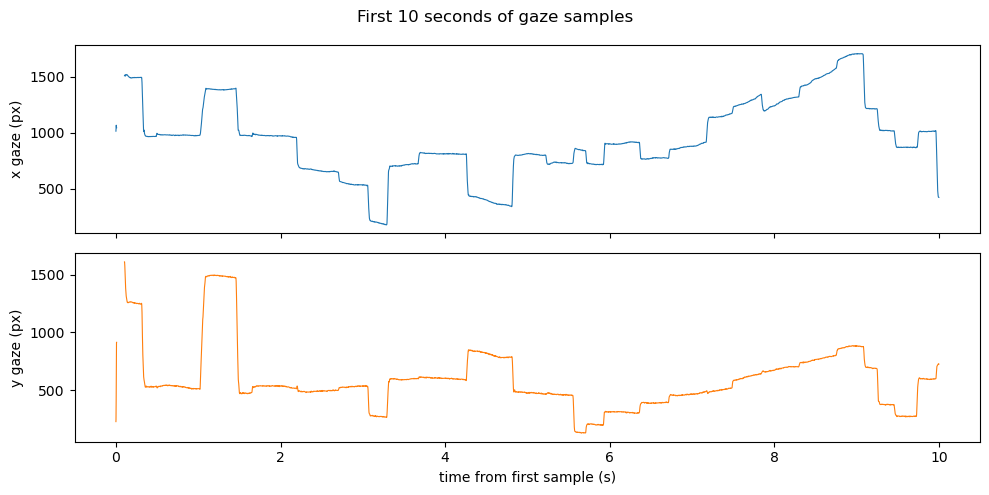

In [26]:
plot_window_ms = 10_000
t0 = samples["time"].iloc[0]
early = samples[samples["time"] <= t0 + plot_window_ms].copy()
early["time_rel_s"] = (early["time"] - t0) / 1000

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(early["time_rel_s"], early["x"], linewidth=0.8)
axes[0].set_ylabel("x gaze (px)")
axes[1].plot(early["time_rel_s"], early["y"], linewidth=0.8, color="tab:orange")
axes[1].set_ylabel("y gaze (px)")
axes[1].set_xlabel("time from first sample (s)")
fig.suptitle("First 10 seconds of gaze samples")
fig.tight_layout()
plt.show()

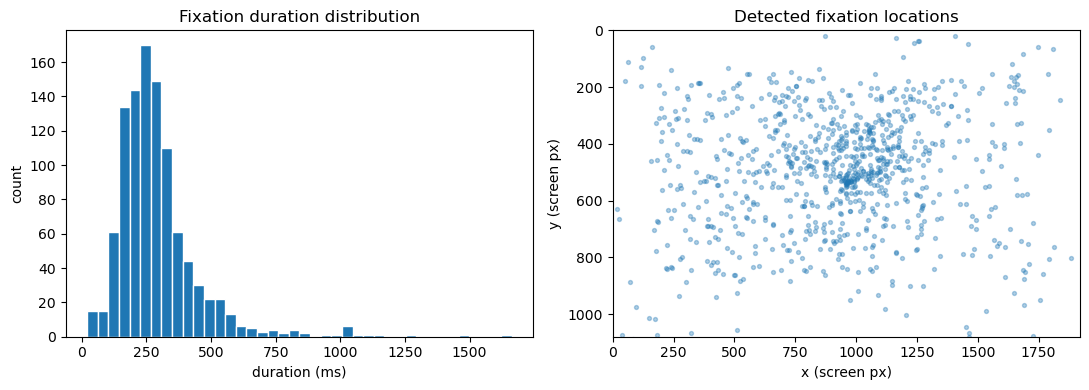

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(fixations["duration"], bins=40, color="tab:blue", edgecolor="white")
axes[0].set_title("Fixation duration distribution")
axes[0].set_xlabel("duration (ms)")
axes[0].set_ylabel("count")

axes[1].scatter(fixations["avg_x"], fixations["avg_y"], s=8, alpha=0.35)
axes[1].invert_yaxis()
axes[1].set_title("Detected fixation locations")
axes[1].set_xlabel("x (screen px)")
axes[1].set_ylabel("y (screen px)")
axes[1].set_xlim(0, 1920)
axes[1].set_ylim(1080, 0)

fig.tight_layout()
plt.show()

In [28]:
summary = pd.DataFrame({
    "measure": [
        "median fixation duration ms",
        "mean fixation duration ms",
        "median saccade amplitude deg",
        "mean blink duration ms",
        "trials with TrialStart marker",
        "trials with Reward marker",
    ],
    "value": [
        fixations["duration"].median(),
        fixations["duration"].mean(),
        saccades["amplitude"].median(),
        blinks["duration"].mean(),
        int((task_markers["marker"] == "TrialStart").sum()),
        int((task_markers["marker"] == "Reward").sum()),
    ],
})
summary

,measure,value
0,median fixation duration ms,261.000000
1,mean fixation duration ms,292.297087
2,median saccade amplitude deg,8.880000
3,mean blink duration ms,88.465278
4,trials with TrialStart marker,11.000000
5,trials with Reward marker,9.000000


## 7. Join trial results to video metadata

After exporting `Results` from MATLAB with `writetable`, Python can read trial-level movie names and success/abort status. This is the table that tells us which videos were actually shown.

In [29]:
RESULTS_CSV = PILOT_DIR / "results.csv"
MANIFEST_CSV = PROJECT_ROOT / "video_ebm_dataset" / "MANIFEST.csv"

if not RESULTS_CSV.exists():
    print("results.csv is missing. In MATLAB, run:")
    print("load('Data/Pilot data/demo_2026-03-05_1439/demo_2026-03-05_1439.mat')")
    print("writetable(Results, 'Data/Pilot data/demo_2026-03-05_1439/results.csv')")
else:
    results = pd.read_csv(RESULTS_CSV)
    manifest = pd.read_csv(MANIFEST_CSV)
    shown = results[results["ImageShown"].notna() & (results["ImageShown"] != "")].copy()
    shown = shown.merge(manifest, left_on="ImageShown", right_on="filename", how="left")

    category_cols = ["video_nature", "video_social_directed", "video_social_undir", "video_boundary", "video_clipped"]
    shown["category"] = shown[category_cols].idxmax(axis=1).str.replace("video_", "")

    print(f"Results rows: {len(results)}")
    print(f"Successful/rewarded trials: {int((results['TrialSuccess'] == 1).sum())}")
    print(f"Aborted trials: {int((results['TrialSuccess'] == 0).sum())}")
    print(f"Boundary videos shown: {int((shown['video_boundary'] == 1).sum())}")
    display(results[["TrialNum", "TrialSuccess", "ImageShown", "AbortPhase"]])
    display(shown[["TrialNum", "ImageShown", "category", "video_boundary", "video_clipped"]])

Results rows: 11
Successful/rewarded trials: 9
Aborted trials: 2
Boundary videos shown: 0


,TrialNum,TrialSuccess,ImageShown,AbortPhase
0,1,1,00393DVD.mpg,NaN
1,2,0,NaN,Hold_fix
2,3,1,neutral_cam_directed05DVD.mpg,NaN
3,4,1,grooming05DVD.mpg,NaN
4,5,1,aggression05DVD.mpg,NaN
5,6,1,sub_cam_directed15DVD.mpg,NaN
6,7,0,NaN,Hold_fix
7,8,1,00303DVD.mpg,NaN
8,9,1,00771DVD.mpg,NaN
9,10,1,aggr_cam_directed10DVD.mpg,NaN


,TrialNum,ImageShown,category,video_boundary,video_clipped
0,1,00393DVD.mpg,nature,0,0
1,3,neutral_cam_directed05DVD.mpg,social_directed,0,0
2,4,grooming05DVD.mpg,social_undir,0,0
3,5,aggression05DVD.mpg,social_undir,0,0
4,6,sub_cam_directed15DVD.mpg,social_directed,0,0
5,8,00303DVD.mpg,nature,0,0
6,9,00771DVD.mpg,nature,0,0
7,10,aggr_cam_directed10DVD.mpg,social_directed,0,0
8,11,foraging10DVD.mpg,social_undir,0,0


Interpretation for this pilot: the shown videos are ordinary `video_all` movies from the manifest. None of the shown rows are marked as `video_boundary=1`.

## 8. What to do next

A sensible next analysis pass would be:

1. Join `trial_timing` to `results` by trial number.
2. Split gaze into enforced-fixation and free-viewing windows.
3. Plot gaze during enforced fixation to check calibration quality.
4. Start category-level summaries using `category` from the manifest.
5. Add real scene-boundary support later only if the task code logs or presents boundary videos.